<a href="https://colab.research.google.com/github/Navya28-khanna/ML_LAB/blob/main/Decision_tree_german_credit_card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import tree

In [2]:
df = pd.read_csv("german credit.data.txt", sep=' ', header=None)

In [3]:
## assign coloumn names
columns = [
'status','duration','credit_history','purpose','credit_amount','savings',
'employment','installment_rate','personal_status','other_debtors',
'residence','property','age','other_installment','housing',
'existing_credits','job','num_people','telephone','foreign_worker','target'
]

df.columns = columns

In [4]:
##Convert Target Variable
df['target'] = df['target'].apply(lambda x: 0 if x==1 else 1)

In [ ]:
## check dataset info
print(df.info())
print(df.describe())
print("Missing values:", df.isnull().sum().sum())

/tmp/ipykernel_3192/946279671.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='RdBu_r')


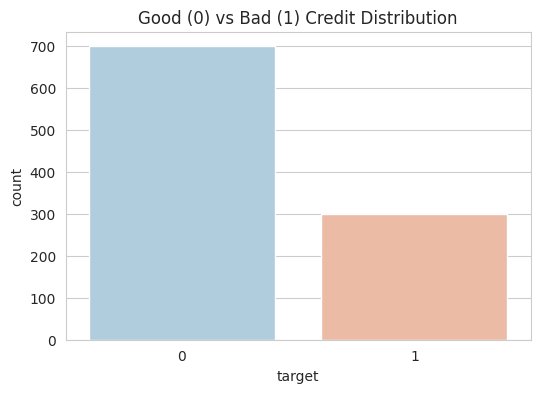

In [5]:
##EDA
sns.set_style('whitegrid')

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='RdBu_r')

plt.title('Good (0) vs Bad (1) Credit Distribution')
plt.show()

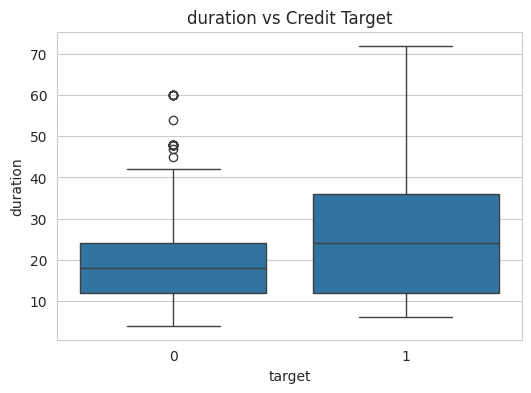

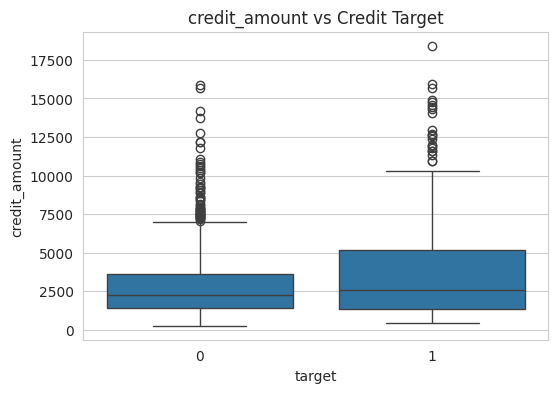

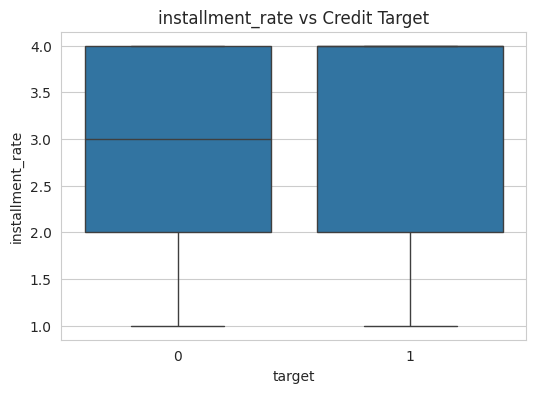

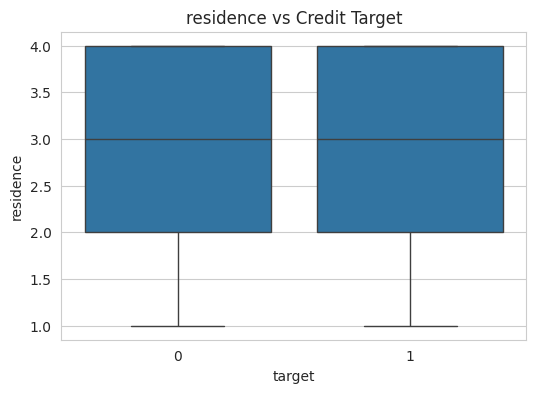

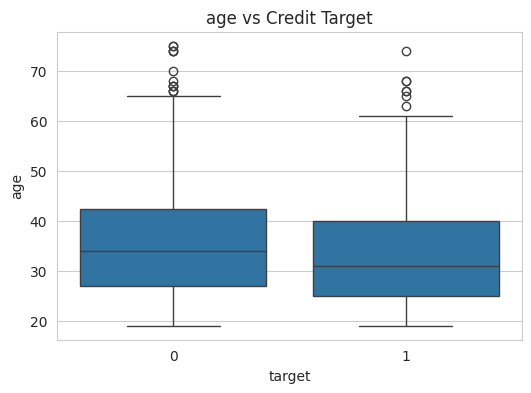

In [6]:
##boxplot
numeric_cols = df.select_dtypes(include=[np.number]).columns[:5]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f'{col} vs Credit Target')
    plt.show()

In [7]:
##convert categorial data
df = pd.get_dummies(df, drop_first=True)

In [8]:
##train test split
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101
)

In [9]:
## train decision tree model
dtree = DecisionTreeClassifier()

dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [10]:
##prediction
predictions = dtree.predict(X_test)

In [11]:
##model evaluation
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[154  50]
 [ 52  44]]
              precision    recall  f1-score   support

           0       0.75      0.75      0.75       204
           1       0.47      0.46      0.46        96

    accuracy                           0.66       300
   macro avg       0.61      0.61      0.61       300
weighted avg       0.66      0.66      0.66       300



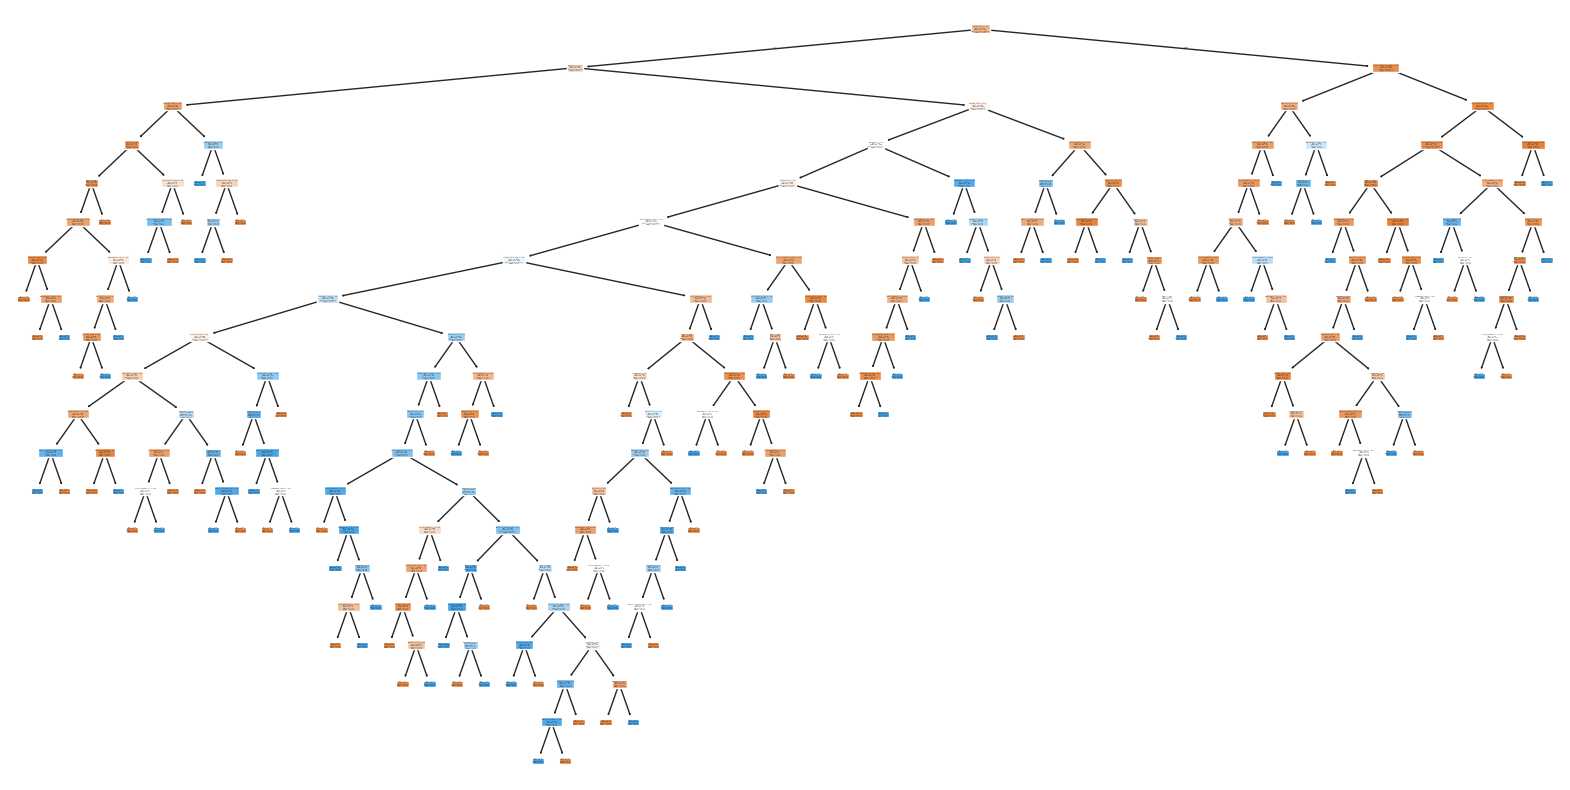

In [12]:
plt.figure(figsize=(20,10))

tree.plot_tree(
    dtree,
    filled=True,
    feature_names=X.columns,
    class_names=['Good','Bad']
)

plt.show()